In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
#3
df = pd.read_excel('./EmployeeSampleData-A.xlsx')
df.iloc[0] = ['E00001', 'Alice Smith', 'Director', 'Executive', 'Corporate', 'Female', 'Caucasian', 45, '2012-05-10', 250000, 0.35, 'United States', 'Seattle', None]
df.iloc[1] = ['E00002', 'lewis Hamiltown', 'Analys', 'IT', 'Corporate', 'Male', 'African American', 48, '2014-08-15', 210000, 0.30, 'United States', 'Austin', None]
df.iloc[2] = ['E02572', 'Luna Sanders', 'Director', 'Finance', 'Speciality Products', 'Female', 'Caucasian', 50, '2006-10-26', 163099, 0.20, 'United States', 'Chicago', None]
df.iloc[3] = ['E02832', 'mostafa Jordan', 'Computer Systems Manager', 'IT', 'Manufacturing', 'Female', 'Caucasian', 26, '2019-09-27', 84913, 0.07, 'United States', 'Chicago', None]
df.iloc[4] = ['E01639', 'mark play', 'Sr. Analyst', 'Finance', 'Manufacturing', 'Male', 'Asian', 55, '1995-11-20', 95409, 0.00, 'United States', 'Phoenix', None]

In [3]:
#2 Gender
df["Gender"] = df["Gender"].fillna("Female")
name_filler = df['Gender'].map({"Female": 'Jane Doe', "Male": 'John Doe'})
df['Full Name'] = df['Full Name'].fillna(name_filler)

#2 Salary
mean_val = df['Annual Salary'].mean()
std_val = df['Annual Salary'].std()
missing_count = df['Annual Salary'].isna().sum()
gaussian_samples = np.random.normal(loc=mean_val, scale=std_val, size=missing_count)
min_salary = df['Annual Salary'].min()
max_salary = df['Annual Salary'].max()
gaussian_samples = np.clip(gaussian_samples, min_salary, max_salary)
df.loc[df['Annual Salary'].isna(), 'Annual Salary'] = gaussian_samples

#2 Rest
columns_to_fill = [
    'Job Title', 'Department', 'Business Unit', 'Ethnicity',
    'Hire Date', 'Bonus %', 'Country', 'City', 'Age'
]
for col in columns_to_fill:
    num_missing = df[col].isna().sum()
    if num_missing > 0:
        random_samples = df[col].dropna().sample(n=num_missing, replace=True).values
        df.loc[df[col].isna(), col] = random_samples

In [4]:
#4
print(df.loc[df['Annual Salary'].idxmax()])

#5
department_summary = df.groupby('Department')[['Age', 'Annual Salary']].mean()
department_summary['Age'] = department_summary['Age'].round(0)
department_summary['Annual Salary'] = department_summary['Annual Salary'].round(0)
print(department_summary)

#6
department_summary2 = df.groupby(['Department', 'Ethnicity']).agg({
    'Age': ['max', 'min'],
    'Annual Salary': ['median']
})
print(department_summary2)

EEID                          E04354
Full Name               Raelynn Rios
Job Title             Vice President
Department                     Sales
Business Unit          Manufacturing
Gender                        Female
Ethnicity                     Latino
Age                             43.0
Hire Date        2016-08-21 00:00:00
Annual Salary               258498.0
Bonus %                         0.35
Country                United States
City                        Columbus
Exit Date                        NaT
Name: 989, dtype: object
                  Age  Annual Salary
Department                          
Accounting       44.0       123147.0
Engineering      46.0       107742.0
Executive        45.0       250000.0
Finance          45.0       121604.0
Human Resources  44.0       117630.0
IT               44.0        98016.0
Marketing        43.0       129663.0
Sales            44.0       111167.0
                                   Age       Annual Salary
                            

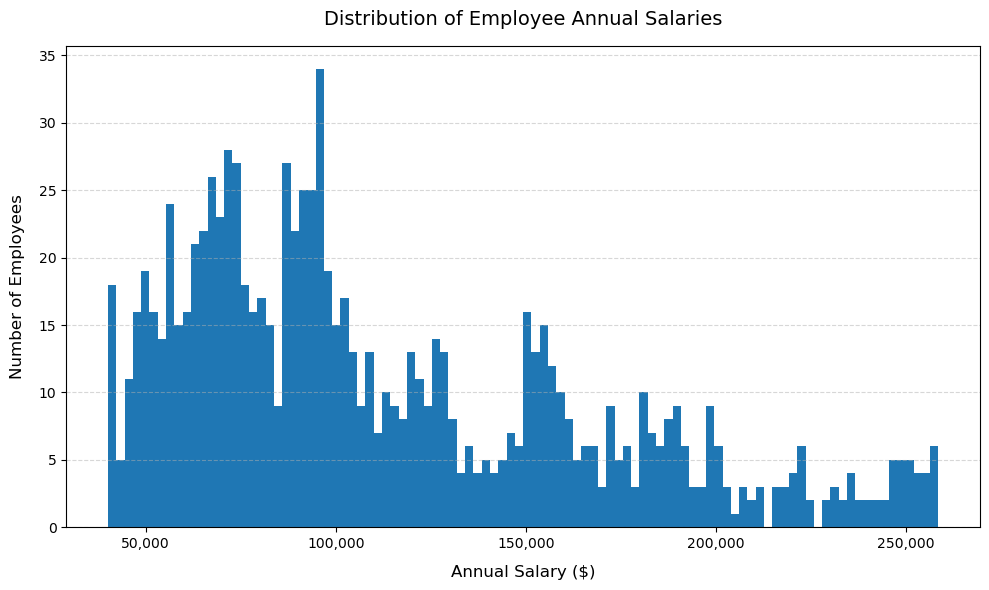

In [5]:
#salary histogram
plt.figure(figsize=(10, 6))
plt.hist(df['Annual Salary'], bins=100)
plt.title('Distribution of Employee Annual Salaries', fontsize=14, pad=15)
plt.xlabel('Annual Salary ($)', fontsize=12, labelpad=10)
plt.ylabel('Number of Employees', fontsize=12, labelpad=10)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

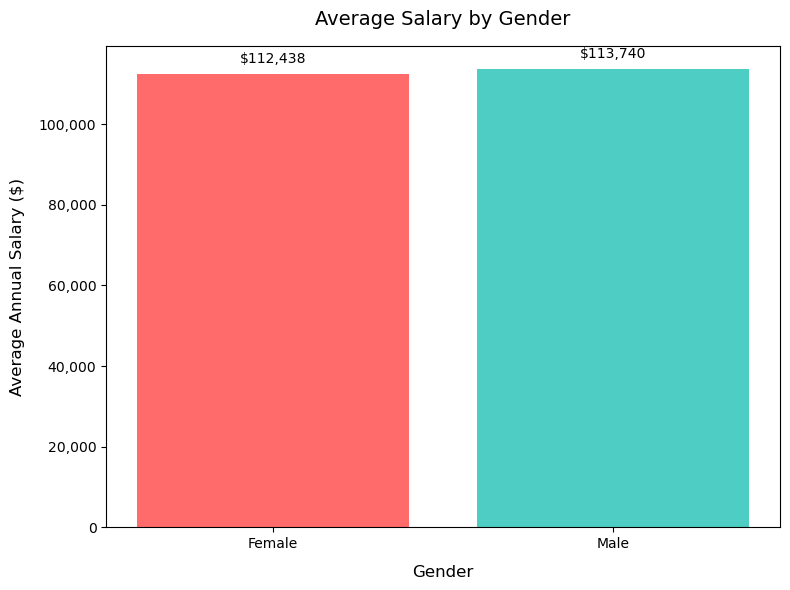

In [6]:
#salary by gender
gender_salary = df.groupby('Gender')['Annual Salary'].mean().round(0)
plt.figure(figsize=(8, 6))
bars = plt.bar(gender_salary.index, gender_salary.values, color=['#FF6B6B', '#4ECDC4'])
plt.title('Average Salary by Gender', fontsize=14, pad=15)
plt.xlabel('Gender', fontsize=12, labelpad=10)
plt.ylabel('Average Annual Salary ($)', fontsize=12, labelpad=10)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2000,
             f'${int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

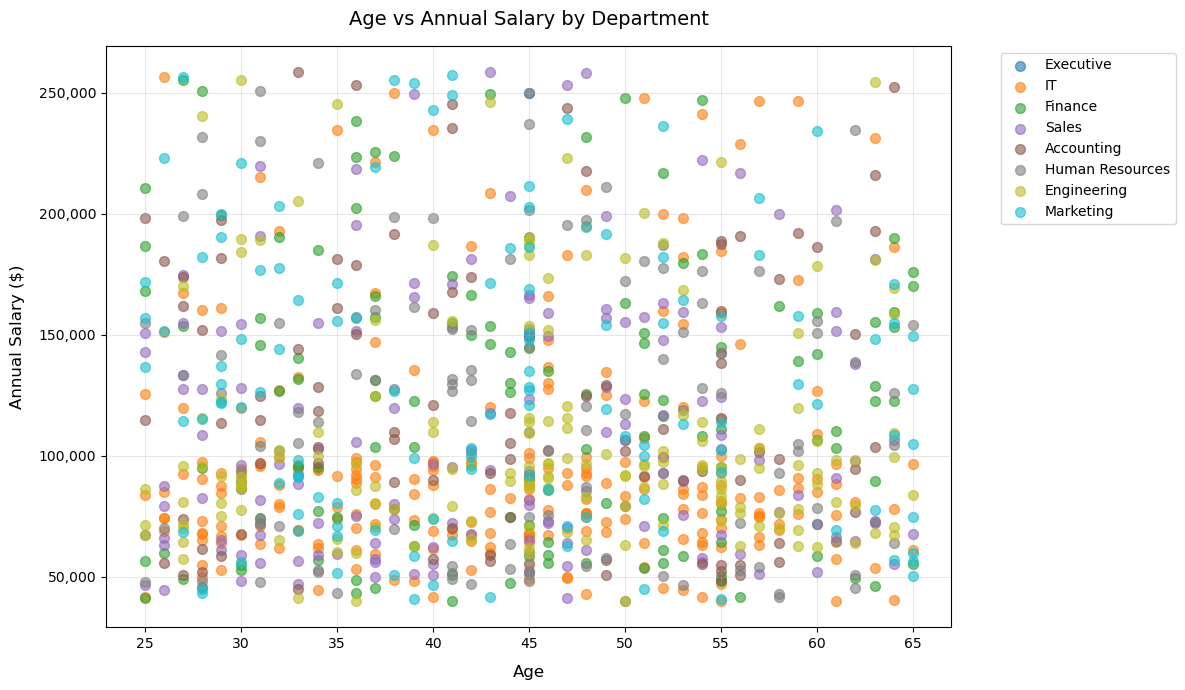

In [7]:
#age vs salary
plt.figure(figsize=(12, 7))
depts = df['Department'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(depts)))

for dept, color in zip(depts, colors):
    dept_data = df[df['Department'] == dept]
    plt.scatter(dept_data['Age'], dept_data['Annual Salary'],
                label=dept, alpha=0.6, s=50, c=[color])

plt.title('Age vs Annual Salary by Department', fontsize=14, pad=15)
plt.xlabel('Age', fontsize=12, labelpad=10)
plt.ylabel('Annual Salary ($)', fontsize=12, labelpad=10)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

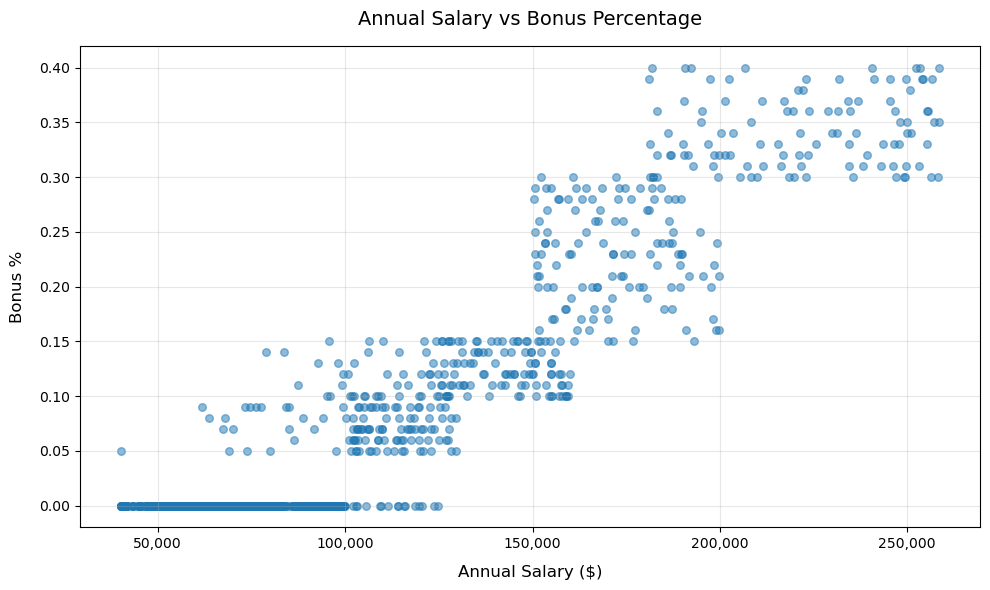

In [8]:
#salary bonus
plt.figure(figsize=(10, 6))
plt.scatter(df['Annual Salary'], df['Bonus %'], alpha=0.5, s=30)
plt.title('Annual Salary vs Bonus Percentage', fontsize=14, pad=15)
plt.xlabel('Annual Salary ($)', fontsize=12, labelpad=10)
plt.ylabel('Bonus %', fontsize=12, labelpad=10)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

df['Annual Salary'] = df['Annual Salary'].map('${:,.0f}'.format)
df['Bonus %'] = df['Bonus %'].map('{:.0%}'.format)
df.to_excel('output.xlsx', index=False)